In [1]:
import numpy as np
import sklearn

_Создадим столбец признаков объекта, которые будут равномерно распределены в отрезке 0-20._

In [37]:
#np.random.rand() - случайные числа 0-1, в скобках размер матрицы
X = 20 * np.random.rand(120, 1)

dtype('float64')

_Создадим гаусовский шум._

In [38]:
noise = np.random.normal(loc=0.0, scale=5, size=X.shape)

array([[ -8.13784638],
       [ -8.40441418],
       [  2.43340196],
       [ -0.22369895],
       [  0.29304279],
       [ -8.04599455],
       [  6.27426598],
       [  2.18515196],
       [-14.09331596],
       [ -4.98238757],
       [ -1.61028582],
       [  8.55043734],
       [  2.03869284],
       [  3.46897449],
       [ -3.13806946],
       [  1.57176184],
       [  3.70445566],
       [ -0.81859144],
       [ -0.79301372],
       [  0.48559571],
       [ -6.8030195 ],
       [  1.48850814],
       [  0.84997648],
       [ -1.92557627],
       [  3.56893036],
       [ -1.42120764],
       [  4.98645843],
       [  6.78222679],
       [ -0.37988014],
       [ -6.37569231],
       [  1.34534692],
       [  4.52452686],
       [  9.03333758],
       [  2.51764213],
       [ -2.08396594],
       [  5.21197806],
       [  0.15191669],
       [ -5.93626883],
       [  5.56766918],
       [ -4.77604141],
       [  1.38667899],
       [ -2.43183277],
       [ -2.13241284],
       [  3

_Создадим правильный ответ и добавим к нему шум._

In [39]:
Y = X * 2 + noise
Y

array([[25.13465776],
       [ 4.04323067],
       [ 5.57065892],
       [25.61676755],
       [32.88950124],
       [ 3.10574357],
       [45.95743935],
       [31.63797842],
       [11.62230929],
       [19.66678361],
       [ 5.98769245],
       [27.31313796],
       [29.55393108],
       [14.46510526],
       [ 5.09684851],
       [14.23969827],
       [25.73656422],
       [11.47732661],
       [26.97372107],
       [34.39833082],
       [31.29365406],
       [ 4.11045452],
       [16.31039374],
       [15.95459799],
       [40.20760101],
       [ 3.63610666],
       [32.63944108],
       [27.94302754],
       [32.14615654],
       [24.8877716 ],
       [36.27316379],
       [29.94451351],
       [46.41175888],
       [42.12421122],
       [37.77082952],
       [23.89395154],
       [20.6439478 ],
       [11.57705913],
       [26.1523752 ],
       [14.39416034],
       [ 8.59158239],
       [-0.50175456],
       [20.41525643],
       [ 3.87479983],
       [14.29840452],
       [14

_Разделим данные на train и test._

In [40]:
from sklearn.model_selection import train_test_split
#40 % процентов тестовой выборки
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

In [41]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((72, 1), (48, 1), (72, 1), (48, 1))

#### **Построим линейную модель.**

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False) #без b
#обучим модель
model.fit(X_train, Y_train)
#посмотрим на её коэффициент
model.coef_

array([[2.02631033]])

_Функция для изображения графиков._

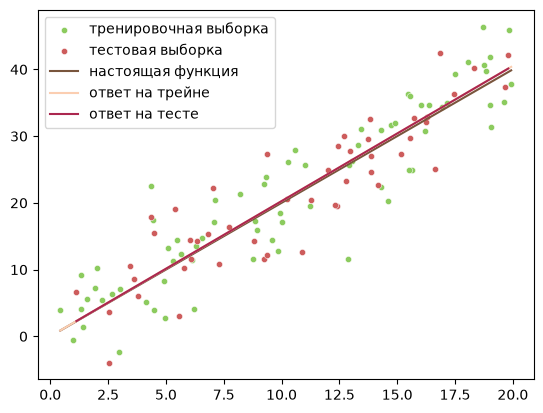

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

def holst(x_train, y_train, x_test, y_test, predict_train, predict_test):
    plt.figure()

    #превращаем все переменные в одномерные массивы
    x_train = np.ravel(x_train)
    y_train = np.ravel(y_train)
    x_test = np.ravel(x_test)
    y_test = np.ravel(y_test)
    predict_train = np.ravel(predict_train)
    predict_test = np.ravel(predict_test)

    #сохраняем индексы для сортировки
    idx_train = np.argsort(x_train)
    idx_test = np.argsort(x_test)

    #изобразим тренировочную выборку
    sns.scatterplot(
        x=x_train,
        y=y_train,
        color="#8ccb5e",
        s=20,
        label="тренировочная выборка"
    )
    #изобразим тестовую выборку
    sns.scatterplot(
        x=x_test,
        y=y_test,
        color="#cd5c5c",
        s=20,
        label="тестовая выборка"
    )
    #изобразим настоящую функцию
    #также сделав векторы одномерными
    sns.lineplot(
        x=np.ravel(X),
        y=np.ravel(2 * X),
        color="#79553d",
        label="настоящая функция"
    )
    #изобразим ответ на трейне
    #отсортировав их по индексам
    sns.lineplot(
        x=x_train[idx_train],
        y=predict_train[idx_train],
        color="#fbceb1",
        label="ответ на трейне"
    )
    #изобразим ответ на тесте
    #отсортировав их по индексам
    sns.lineplot(
        x=x_test[idx_test],
        y=predict_test[idx_test],
        color="#ab274f",
        label="ответ на тесте"
    )
    #отобразим легенду
    plt.legend()
    #отобразим весь график
    plt.show()
holst(X_train, Y_train, X_test, Y_test, model.predict(X_train), model.predict(X_test))

#### **Построим полиномиальную модель.**

_Добавим степенные признаки._

In [44]:
#скопируем старые признаки
X_pol = X.copy()
#добавим новые признаки
for k in range(2, 26):
    x_new = X ** k
    X_pol = np.hstack([X_pol, x_new])
X_pol.shape

(120, 25)

_Снова разделим выборку на тестовую и трейн._

In [45]:
X_pol_train, X_pol_test, Y_pol_train, Y_pol_test = train_test_split(X_pol, Y, test_size=0.4, random_state=42)

In [46]:
X_pol_train.shape, X_pol_test.shape

((72, 25), (48, 25))

_Обучим новую модель._

In [47]:
model_pol = LinearRegression()
model_pol.fit(X_pol_train, Y_pol_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 25)","[[ 0., 0.,-0.,..., 0.,-0., 0.]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[15.53]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,25
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](25,)","[4.82e+32,4.80e+29,7.61e+26,...,8.95e+00,1.77e-01,3.16e-06]"


_Изобразим её._

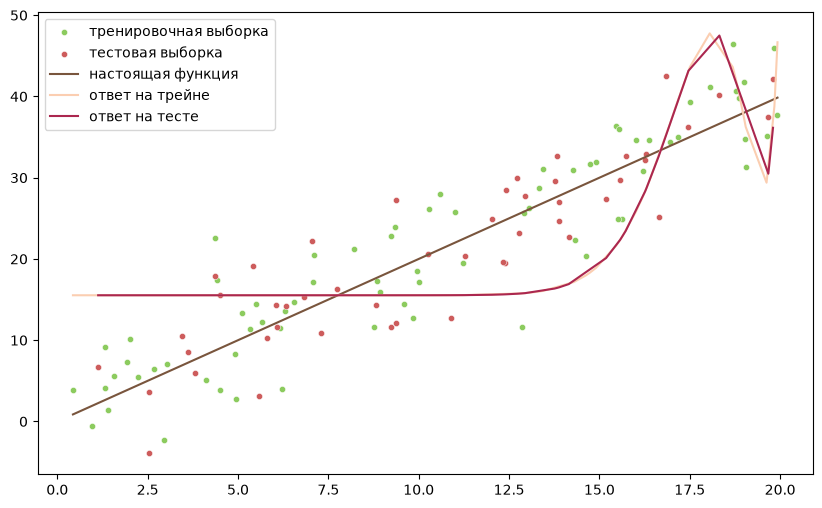

In [48]:
#найдем ответы для трейна
ans_train = model_pol.predict(X_pol_train)
#найдем ответы для теста
ans_test = model_pol.predict(X_pol_test)

#передаем в функцию только первый столбец признаков
holst(X_pol_train[:, 0], Y_pol_train, X_pol_test[:, 0], Y_pol_test, ans_train, ans_test)